In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [5]:
# ==========================================================
# CONFIGURATION
# ==========================================================

BASE_DIR = Path.cwd().parent

INPUT_FILE = BASE_DIR / "data" / "features" / "customer_feature_dataset.csv"

OUTPUT_DIR = BASE_DIR / "data" / "model"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "customer_model_dataset.csv"

In [6]:
df = pd.read_csv(INPUT_FILE)

print("=" * 70)
print("FEATURE DATASET LOADED")
print("=" * 70)

print()

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

FEATURE DATASET LOADED

Rows    : 363,569
Columns : 91


In [8]:
print("=" * 70)
print("DATASET VALIDATION")
print("=" * 70)

print()

print("Duplicate customers :", df["CUSTOMER_NO"].duplicated().sum())

print("Missing CUSTOMER_NO :", df["CUSTOMER_NO"].isna().sum())

print()

display(df.head())

DATASET VALIDATION

Duplicate customers : 0
Missing CUSTOMER_NO : 0



,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,COMPLETED_FILE,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCOUNT_STATUS,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCOUNT_TYPE_DESC,CURRENCY,ACCT_CLOSE_DATE,CLOSURE_REASON,ACCT_BALANCE,INDUSTRY,SALARY,PRODUCT_GROUP,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB,AGE,AGE_GROUP,CUSTOMER_TENURE_YEARS,IS_TUNISIAN,IS_RESIDENT,CUSTOMER_SEGMENT,MARITAL_STATUS_GROUP,NB_ACCOUNTS,ACTIVE_ACCOUNTS,CLOSED_ACCOUNTS,TOTAL_BALANCE,AVG_BALANCE,MAX_BALANCE,MIN_BALANCE,ACCOUNT_DIVERSITY,HAS_MULTIPLE_ACCOUNTS,HAS_ACTIVE_ACCOUNT,HAS_CLOSED_ACCOUNT,ACTIVE_ACCOUNT_RATIO,HAS_POSITIVE_SALARY,HAS_POSITIVE_BALANCE,HAS_NEGATIVE_BALANCE,HAS_ZERO_TOTAL_BALANCE,HIGH_VALUE_CUSTOMER,SALARY_LEVEL,BALANCE_LEVEL,BALANCE_TO_SALARY_RATIO,NB_PRODUCTS,NB_PRODUCT_GROUPS,NB_PRODUCT_LINES,HAS_LOAN,HAS_SAVINGS,HAS_DEPOSIT,HAS_CURRENT_ACCOUNT,PRODUCT_DIVERSITY,KYC_RISK_LEVEL,FILE_COMPLETED_FLAG,LOW_KYC_RISK,MEDIUM_KYC_RISK,HIGH_KYC_RISK,VERY_HIGH_KYC_RISK,DAYS_SINCE_LAST_REVIEW,DAYS_TO_NEXT_REVIEW,REVIEW_OVERDUE,HAS_REVIEW_HISTORY,HAS_NEXT_REVIEW_DATE,REVIEW_STATUS,NB_BRANCHES,NB_INDUSTRIES,NB_LOB,NB_CURRENCIES,MAIN_BRANCH,MAIN_INDUSTRY,MAIN_LOB,MAIN_CURRENCY,IS_MULTI_BRANCH,IS_MULTI_CURRENCY
0,112872078,2.010326e+09,TN,TN,UNKNOWN,NaN,NaN,UNKNOWN,5801,H2,UNKNOWN,2023-09-22,2025-09-21,Active,2023-02-27,8902.0,AVA ATB,TND,NaN,NOT_APPLICABLE,589747.163,1814,612.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,AVA ATB,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Corporate,30,NaN,NaN,NaN,1,1,Corporate,UNKNOWN,59,59,0,748225.554,12681.789051,2833259.331,-1641095.767,17,1,1,0,1.0,1,1,1,0,1,LOW,VERY_HIGH,1222.590775,0,0,0,0,0,0,0,0,H2,0,0,0,1,1,881.0,-151.0,1,1,1,OVERDUE,1,1,1,3,5801,1814,30,TND,0,1
1,112872083,2.011459e+09,TN,TN,UNKNOWN,NaN,NaN,UNKNOWN,11,LR,UNKNOWN,NaN,NaN,Active,2025-12-31,8014.0,COMPTE BROKER,TND,NaN,NOT_APPLICABLE,0.000,3100,612.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,COMPTE BROKER,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Corporate,30,NaN,NaN,NaN,1,1,Corporate,UNKNOWN,14,14,0,0.000,0.000000,0.000,0.000,2,1,1,0,1.0,1,0,0,1,0,LOW,ZERO,0.000000,0,0,0,0,0,0,0,0,LR,0,1,0,0,0,NaN,NaN,0,0,0,UNKNOWN,1,1,1,1,11,3100,30,TND,0,0
2,113072080,2.010915e+09,TN,TN,UNKNOWN,NaN,NaN,PM,5802,MR,UNKNOWN,NaN,NaN,Active,2025-02-03,8930.0,DEPOT A TERME CLIENT NON ATB,TND,NaN,NOT_APPLICABLE,0.000,111,612.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,DEPOT A TERME CLIENT NON ATB,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Corporate,13,NaN,NaN,NaN,1,1,Corporate,UNKNOWN,2,2,0,0.000,0.000000,0.000,0.000,1,1,1,0,1.0,1,0,0,1,0,LOW,ZERO,0.000000,0,0,0,0,0,1,0,0,MR,0,0,1,0,0,NaN,NaN,0,0,0,UNKNOWN,1,1,1,2,5802,111,13,TDC,0,1
3,113073073,2.001489e+09,TN,TN,C,2020-10-08,2002-02-20,PPH,5890,LR,YES,2024-09-25,2028-09-24,Closed,NaN,NaN,NOT_APPLICABLE,NOT_APPLICABLE,2024-12-04,ATB.REASON.13,NaN,9000,400.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Retail,4,24.0,18-25,5.4,1,1,Retail,C,1,0,1,0.000,0.000000,0.000,0.000,0,0,0,1,0.0,1,0,0,1,0,LOW,ZERO,0.000000,0,0,0,0,0,0,0,0,LR,1,1,0,0,0,512.0,948.0,0,1,1,PLANNED_LATER,1,1,1,0,5890,9000,4,UNKNOWN,0,0
4,113073074,2.003284e+09,TN,TN,M,2020-10-08,1977-08-17,PPH,5890,LR,YES,2025-08-06,2029-08-05,Active,2020-10-08,6001.0,Comptes Spéciaux d épargne,TND,NaN,NOT_APPLICABLE,2001.000,9000,600.0,ATB.GRP.EPARGNE.ACCT,ACCOUNTS,ATB.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,2001.0,NaN,NOT_APPLICABLE,Retail,4,49.0,46-55,5.4,1,1,Retail,M,1,1,0,2001.000,2001.000000,2001.000,2001.000,1,0,1,0,1.0,1,1,0,0,0,LOW,MEDIUM,3.335000,1,1,1,0,1,0,0,3,LR,1,1,0,0,0,197.0,1263.0,0,1,1,PLANNED_LATER,1,1,1,1,5890,9000,4,TND,0,0


In [9]:
# ==========================================================
# BUSINESS RULE FOR CHURN
# ==========================================================

df["TARGET_CHURN"] = np.where(
    (df["ACCOUNT_STATUS"] == "Closed") &
    (df["HAS_ACTIVE_ACCOUNT"] == 0),
    1,
    0
)

print("=" * 70)
print("TARGET CREATED")
print("=" * 70)

display(df["TARGET_CHURN"].value_counts())

display(
    (
        df["TARGET_CHURN"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
)

TARGET CREATED


TARGET_CHURN
0    246211
1    117358
Name: count, dtype: int64

TARGET_CHURN
0    67.72
1    32.28
Name: proportion, dtype: float64

In [10]:
print("=" * 70)
print("TARGET VALIDATION")
print("=" * 70)

summary = pd.DataFrame({
    "Class": ["Non Churn", "Churn"],
    "Count": df["TARGET_CHURN"].value_counts().sort_index().values
})

summary["Percentage"] = (
    summary["Count"] / len(df) * 100
).round(2)

display(summary)

TARGET VALIDATION


,Class,Count,Percentage
0,Non Churn,246211,67.72
1,Churn,117358,32.28


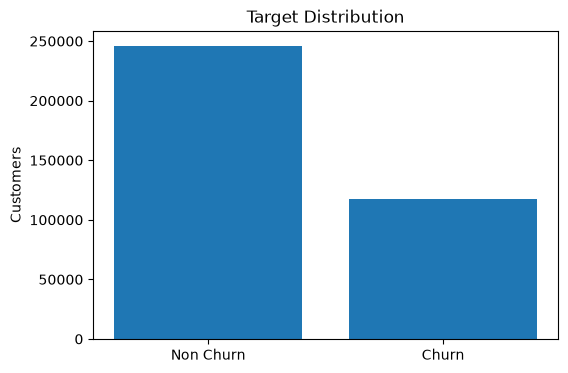

In [11]:
import matplotlib.pyplot as plt

counts = df["TARGET_CHURN"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(
    ["Non Churn","Churn"],
    counts.values
)

plt.title("Target Distribution")

plt.ylabel("Customers")

plt.show()

In [12]:
df.to_csv(OUTPUT_FILE, index=False)

print("=" * 70)
print("MODEL DATASET EXPORTED")
print("=" * 70)

print(OUTPUT_FILE)
print(df.shape)

MODEL DATASET EXPORTED
c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\data\model\customer_model_dataset.csv
(363569, 92)
